<a href="https://colab.research.google.com/github/sofialindner/ntl-urban-expansion-mapping/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import geopandas as gpd

# Lê shapefile
cities = gpd.read_file("LITORAL_SC_REPROJETADO.shp")

# Normaliza tipo de cada atributo
cities["CD_MUN"] = cities["CD_MUN"].astype(int)
cities["NM_MUN"] = cities["NM_MUN"].astype(str)

# Indexa dados de cada município por código
cities_by_code = {
    row["CD_MUN"]: {
        "name": row["NM_MUN"],
        "geometry": row.geometry,
        "row": row
    }
    for _, row in cities.iterrows()
}

In [ ]:
# Intervalo de anos
YEARS = ["2015", "2016", "2017", "2018", "2019", "2020", "2021", "2022", "2023", "2024", "2025"]

# Intervalo de meses
MONTHS = ["01", "02", "03", "04", "05", "06", "07", "08", "09", "10", "11", "12"]

# Lista de cidades separados por região
CITIES_BY_REGION = {
  "blumenau": [
    4202008,
    4202107,
    4202453,
    4208203,
    4208302,
    4211306,
    4212502,
    4212809,
    4213500,
    4218004,
  ],
  "florianopolis": [
    4202305,
    4205407,
    4205704,
    4206009,
    4207304,
    4211900,
    4212304,
    4216602,
  ],
  "joinville": [4201307, 4202057, 4208450, 4216206],
  "criciuma": [4220000, 4201406, 4201950, 4202073, 4212254, 4208807, 4209409],
}

In [ ]:
from huggingface_hub import snapshot_download
from glob import glob
import rasterio

# Baixa dataset inteiro mantendo estrutura
dataset_path = snapshot_download(
    repo_id="incrisvel/ntl-urban-expansion",
    repo_type="dataset"
)

In [ ]:
import pickle
import rasterio
from rasterio.mask import mask
import numpy as np
from glob import glob
from pathlib import Path
import re

base_path = Path(dataset_path)

# Diretório para persistência
output_dir = Path("processed/series")
output_dir.mkdir(exist_ok=True)

# Utlitário para indexação
def timestamp_from_path(path):
    filename = Path(path).stem

    match = re.search(r'_(\d{4})_(\d{2})_', filename)
    if not match:
        raise ValueError(
            f"Não foi possível extrair ano/mês de {filename}"
        )

    year = match.group(1)
    month = match.group(2)

    return f"{year}-{month}"


for region_name, city_codes in CITIES_BY_REGION.items():

    print(f"\nREGIÃO: {region_name}")

    # Estrutura da região inteira
    pixel_series_by_city = {
        city_code: {}
        for city_code in city_codes
    }

    for year in YEARS:

        image_paths = sorted(
            glob(str(base_path / f"{region_name}/{year}/*.tif"))
        )

        for path in image_paths:
            print(path)

            # Extrai timestamp
            timestamp = timestamp_from_path(path)

            # Abre raster da região
            with rasterio.open(path) as src:

                for city_code in city_codes:

                    city = cities_by_code[city_code]

                    # Extrai atributos do município
                    city_name = city["name"]
                    city_geometry = city["geometry"]

                    print(f"  Município: {city_name}")

                    try:
                       # Recorta raster pelo município
                        out_image, out_transform = mask(
                            src,
                            [city_geometry],
                            crop=True
                        )

                    except ValueError as e:

                        # Município completamente fora da imagem
                        if "Input shapes do not overlap raster" in str(e):
                            continue

                    img = out_image[0]

                    # Verifica valor usado no .tif para nodata
                    nodata = src.nodata

                    valid_mask = np.isfinite(img)

                    # Filtra valores nodata
                    if nodata is not None:
                        valid_mask &= (img != nodata)

                    rows, cols = np.where(valid_mask)

                    for row, col in zip(rows, cols):

                        value = img[row, col]

                        if not np.isfinite(value):
                            continue

                        # Coordenadas geográficas reais
                        x, y = rasterio.transform.xy(
                            out_transform,
                            row,
                            col
                        )

                        # Arredonda coordenadas para evitar diferenças de ponto flutuante
                        key = (
                            round(x, 6),
                            round(y, 6)
                        )

                        # Cria chave do pixel a partir das coordenadas
                        if key not in pixel_series_by_city[city_code]:
                            pixel_series_by_city[city_code][key] = {}

                        # Armazena luminosidade indexada por ano-mês
                        pixel_series_by_city[city_code][key][timestamp] = float(value)

    # Persistência ao final da região
    for city_code in city_codes:

        city = cities_by_code[city_code]

        city_name = city["name"]

        output_path = output_dir / f"{city_code}_{city_name}.pkl"

        with open(output_path, "wb") as f:
            pickle.dump(
                {
                    "city_code": city_code,
                    "city_name": city_name,
                    "pixels": pixel_series_by_city[city_code]
                },
                f,
                protocol=pickle.HIGHEST_PROTOCOL
            )

        print(f"Salvo: {output_path}")


REGIÃO: blumenau
/root/.cache/huggingface/hub/datasets--incrisvel--ntl-urban-expansion/snapshots/fcb87e1d852b60d351aeaa77c0bb37f50a63053b/blumenau/2015/VIIRS_NTL_MedianaMensal_Blumenau_2015_01_reprojetada.tif
  Município: BalneÃ¡rio CamboriÃº
  Município: Barra Velha
  Município: Bombinhas
  Município: ItajaÃ­
  Município: Itapema
  Município: Navegantes
  Município: Penha
  Município: BalneÃ¡rio PiÃ§arras
  Município: Porto Belo
  Município: Tijucas
/root/.cache/huggingface/hub/datasets--incrisvel--ntl-urban-expansion/snapshots/fcb87e1d852b60d351aeaa77c0bb37f50a63053b/blumenau/2015/VIIRS_NTL_MedianaMensal_Blumenau_2015_02_reprojetada.tif
  Município: BalneÃ¡rio CamboriÃº
  Município: Barra Velha
  Município: Bombinhas
  Município: ItajaÃ­
  Município: Itapema
  Município: Navegantes
  Município: Penha
  Município: BalneÃ¡rio PiÃ§arras
  Município: Porto Belo
  Município: Tijucas
/root/.cache/huggingface/hub/datasets--incrisvel--ntl-urban-expansion/snapshots/fcb87e1d852b60d351aeaa77c0

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression


def pixel_linear_trend(serie):
    """
    Calcula a inclinação de uma série temporal e permite identificar:
    - Crescimento
    - Estabilidade
    - Decaimento
    """
    y = np.array(serie, dtype=float)

    # Filtra valores NaN
    valid = ~np.isnan(y)
    y = y[valid]

    # Não tenta calcular regressão para séries pequenas
    if len(y) < 2:
        return 0.0

    X = np.arange(len(y)).reshape(-1, 1)

    model = LinearRegression()
    model.fit(X, y)

    return float(model.coef_[0])


def pixel_seasonality(pixel_data):
    """
    Mede sazonalidade através da diferença entre
    luminosidade média do verão e do inverno.
    """
    SUMMER_MONTHS = [12, 1, 2]
    WINTER_MONTHS = [6, 7, 8]

    summer = []
    winter = []

    for timestamp, value in pixel_data.items():

        month = int(timestamp.split("-")[1])

        if month in SUMMER_MONTHS:
            summer.append(value)

        elif month in WINTER_MONTHS:
            winter.append(value)

    if len(summer) == 0 or len(winter) == 0:
        return 0.0

    return float(np.mean(summer) - np.mean(winter))


def pixel_growth_rate(serie):
    """
    Mede crescimento acumulado na série temporal.
    """
    if len(serie) < 2:
        return 0.0

    first = serie[0]
    last = serie[-1]

    if first == 0:
        return 0.0

    return (last - first) / first

In [ ]:
from pathlib import Path
import pickle
import numpy as np

series_dir = Path("processed/series")
features_dir = Path("processed/features")

features_dir.mkdir(
    parents=True,
    exist_ok=True
)

def extract_pixel_features(serie: np.ndarray) -> dict:
    return {
        "mean": np.mean(serie),
        "var": np.var(serie),
        "max": np.max(serie),
        "min": np.min(serie),
        "linear_trend": pixel_linear_trend(serie),
        "seasonality": pixel_seasonality(pixel_data),
        "growth_rate": pixel_growth_rate(serie),
        "position": position
    }

for city_pickle in series_dir.glob("*.pkl"):

    print(city_pickle.name)

    with open(city_pickle, "rb") as f:
        city_data = pickle.load(f)

    pixel_features = {}

    for position, pixel_data in city_data["pixels"].items():

        ordered_values = [
            pixel_data[timestamp]
            for timestamp in sorted(pixel_data.keys())
        ]

        serie = np.array(
            ordered_values,
            dtype=float
        )

        if len(serie) < 2:
            continue

        pixel_features[position] = {
            "overall": extract_pixel_features(serie),
            "first_year": extract_pixel_features(serie[:12]),
            "last_year": extract_pixel_features(serie[-12:])
        }

    output = {
        "city_code": city_data["city_code"],
        "city_name": city_data["city_name"],
        "features": pixel_features
    }

    output_path = (
        features_dir /
        city_pickle.name
    )

    with open(output_path, "wb") as f:
        pickle.dump(
            output,
            f,
            protocol=pickle.HIGHEST_PROTOCOL
        )

4206009_Governador Celso Ramos.pkl
4208450_ItapoÃ¡.pkl
4202305_BiguaÃ§u.pkl
4202073_BalneÃ¡rio Gaivota.pkl
4220000_BalneÃ¡rio RincÃ£o.pkl
4216206_SÃ£o Francisco do Sul.pkl
4208302_Itapema.pkl
4213500_Porto Belo.pkl
4202107_Barra Velha.pkl
4212502_Penha.pkl
4202008_BalneÃ¡rio CamboriÃº.pkl
4208807_Jaguaruna.pkl
4211900_PalhoÃ§a.pkl
4201307_Araquari.pkl
4202057_BalneÃ¡rio Barra do Sul.pkl
4205407_FlorianÃ³polis.pkl
4212304_Paulo Lopes.pkl
4201406_AraranguÃ¡.pkl
4212254_Passo de Torres.pkl
4218004_Tijucas.pkl
4205704_Garopaba.pkl
4207304_Imbituba.pkl
4211306_Navegantes.pkl
4202453_Bombinhas.pkl
4212809_BalneÃ¡rio PiÃ§arras.pkl
4208203_ItajaÃ­.pkl
4201950_BalneÃ¡rio Arroio do Silva.pkl
4209409_Laguna.pkl
4216602_SÃ£o JosÃ©.pkl


In [ ]:
'''
Utilitário para exportar resumo da clusterização
'''
def export_cluster_summary(
    cluster_summary,
    cluster_labels,
    silhouette,
    davies_bouldin,
    city_code,
    city_name,
    serie_type
):
  summary_export = cluster_summary.copy()

  # Mapeia clusters com categorias
  summary_export["category"] = (
      summary_export.index
      .map(cluster_labels)
  )

  # Armazena métricas de desempenho
  summary_export["silhouette_score"] = silhouette

  summary_export["davies_bouldin_score"] = davies_bouldin

  summary_export.to_csv(
      summary_dir /
      f"{city_code}_{city_name}_{serie_type}.csv"
  )

In [ ]:
from typing import Literal
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score
)
import pandas as pd

summary_dir = Path("processed/summaries")
summary_dir.mkdir(
    parents=True,
    exist_ok=True
)

def clusterize_pixels_features(
    features: dict,
    serie_type: Literal["overall", "start_year", "end_year"],
    city_code: int,
    city_name: str
) -> dict:
    df = pd.DataFrame(features.values())

    # Remove pixels sem atividade e ruídos
    df = df[df["mean"] > 1]
    df = df[df["max"] > 2]

    X = df[
        [
            "mean",
            "var",
            "linear_trend",
            "seasonality",
            "growth_rate"
        ]
    ]

    # Normaliza os valores de cada feature
    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X)

    # Calcula KMeans para o município
    kmeans = KMeans(
        n_clusters=4,
        random_state=1,
        n_init="auto"
    )

    df["cluster"] = kmeans.fit_predict(X_scaled)

    if len(df) < 10:
      return None

    silhouette = silhouette_score(
        X_scaled,
        df["cluster"]
    )

    davies_bouldin = davies_bouldin_score(
        X_scaled,
        df["cluster"]
    )

    cluster_summary = (
        df.groupby("cluster")
          .agg({
              "mean": "mean",
              "var": "mean",
              "linear_trend": "mean",
              "growth_rate": "mean",
              "seasonality": "mean"
          })
          .round(3)
    )

    cluster_summary["expansion_score"] = (
        cluster_summary["linear_trend"] +
        cluster_summary["growth_rate"]
    )

    cluster_summary["pixel_count"] = (
        df.groupby("cluster")
          .size()
    )

    # Conjunto para controlar quais clusters já receberam label
    assigned = set()

    # Encontra cluster em EXPANSÃO
    expansion_cluster = (
        cluster_summary["expansion_score"]
        .idxmax()
    )
    assigned.add(expansion_cluster)

    # Encontra cluster CONSOLIDADO
    urban_candidates = (
        cluster_summary
        .drop(index=list(assigned))
    )
    urban_cluster = (
        urban_candidates["mean"]
        .idxmax()
    )
    assigned.add(urban_cluster)

    # Encontra cluster SAZONAL
    seasonal_candidates = (
        cluster_summary
        .drop(index=list(assigned))
    )
    seasonal_cluster = (
        seasonal_candidates["seasonality"]
        .idxmax()
    )
    assigned.add(seasonal_cluster)

    # Encontra cluster com BAIXA ATIVIDADE
    inactive_cluster = (
        cluster_summary
        .drop(index=list(assigned))
        .index[0]
    )

    # Atribui labels ao índice de cada cluster
    cluster_labels = {
        inactive_cluster: "LOW_ACTIVITY",
        urban_cluster: "URBAN",
        expansion_cluster: "EXPANSION",
        seasonal_cluster: "SEASONAL"
    }
    df["cluster_type"] = df["cluster"].map(cluster_labels)


    # Salva interpretação dos clusters
    export_cluster_summary(
        cluster_summary=cluster_summary,
        cluster_labels=cluster_labels,
        silhouette=silhouette,
        davies_bouldin=davies_bouldin,
        city_code=city_code,
        city_name=city_name,
        serie_type=serie_type
    )

    return {
        "cluster_summary": cluster_summary,
        "cluster_labels": cluster_labels,

        "silhouette_score": silhouette,
        "davies_bouldin_score": davies_bouldin,

        "expansion_cluster": expansion_cluster,
        "seasonal_cluster": seasonal_cluster,
        "urban_cluster": urban_cluster,
        "inactive_cluster": inactive_cluster,

        "data": df
    }

In [ ]:
from pathlib import Path
import pandas as pd
import pickle

clusters_dir = Path("processed/clusters")
features_dir = Path("processed/features")

clusters_dir.mkdir(
    parents=True,
    exist_ok=True
)

for feature_pickle in features_dir.glob("*.pkl"):

    print(feature_pickle.name)

    with open(feature_pickle, "rb") as f:
        city_data = pickle.load(f)

    features = city_data["features"]

    overall_features = {
        position: data["overall"]
        for position, data in features.items()
    }

    first_year_features = {
        position: data["first_year"]
        for position, data in features.items()
    }

    last_year_features = {
        position: data["last_year"]
        for position, data in features.items()
    }

    cluster_result = {
        "city_code": city_data["city_code"],
        "city_name": city_data["city_name"],
        "clusters": {
            "first_year": clusterize_pixels_features(
                first_year_features,
                "first_year",
                city_data["city_code"],
                city_data["city_name"]
            ),
            "last_year": clusterize_pixels_features(
                last_year_features,
                "last_year",
                city_data["city_code"],
                city_data["city_name"]
            ),
            "overall": clusterize_pixels_features(
                overall_features,
                "overall",
                city_data["city_code"],
                city_data["city_name"]
            )
        }
    }

    output_path = (clusters_dir / feature_pickle.name)

    # Salva pickle do cluster
    with open(output_path, "wb") as f:
        pickle.dump(
            cluster_result,
            f,
            protocol=pickle.HIGHEST_PROTOCOL
        )

4206009_Governador Celso Ramos.pkl
4208450_ItapoÃ¡.pkl
4202305_BiguaÃ§u.pkl
4202073_BalneÃ¡rio Gaivota.pkl
4220000_BalneÃ¡rio RincÃ£o.pkl
4216206_SÃ£o Francisco do Sul.pkl
4208302_Itapema.pkl
4213500_Porto Belo.pkl
4202107_Barra Velha.pkl
4212502_Penha.pkl
4202008_BalneÃ¡rio CamboriÃº.pkl
4208807_Jaguaruna.pkl
4211900_PalhoÃ§a.pkl
4201307_Araquari.pkl
4202057_BalneÃ¡rio Barra do Sul.pkl
4205407_FlorianÃ³polis.pkl
4212304_Paulo Lopes.pkl
4201406_AraranguÃ¡.pkl
4212254_Passo de Torres.pkl
4218004_Tijucas.pkl
4205704_Garopaba.pkl
4207304_Imbituba.pkl
4211306_Navegantes.pkl
4202453_Bombinhas.pkl
4212809_BalneÃ¡rio PiÃ§arras.pkl
4208203_ItajaÃ­.pkl
4201950_BalneÃ¡rio Arroio do Silva.pkl
4209409_Laguna.pkl
4216602_SÃ£o JosÃ©.pkl


In [ ]:
from pathlib import Path
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

clusters_dir = Path("processed/clusters")
plots_dir = Path("processed/plots")

plots_dir.mkdir(
    parents=True,
    exist_ok=True
)

CATEGORY_COLORS = {
    "LOW_ACTIVITY": 0,
    "URBAN": 1,
    "EXPANSION": 2,
    "SEASONAL": 3
}

cluster_cmap = ListedColormap([
    "#d3d3d3",  # LOW_ACTIVITY
    "#1f77b4",  # URBAN
    "#2ca02c",  # EXPANSION
    "#ff7f0e",  # SEASONAL
])

def save_plot_for_serie(
    df: pd.DataFrame,
    city_data: dict,
    serie_type: Literal["overall", "first_year", "last_year"]
):
    # Recupera coordenadas
    df["x"] = df["position"].apply(lambda p: p[0])
    df["y"] = df["position"].apply(lambda p: p[1])

    # Reconstrói grade espacial
    x_unique = np.sort(df["x"].unique())
    y_unique = np.sort(df["y"].unique())

    cluster_img = np.full(
        (len(y_unique), len(x_unique)),
        np.nan
    )

    x_index = {
        value: idx
        for idx, value in enumerate(x_unique)
    }

    y_index = {
        value: idx
        for idx, value in enumerate(y_unique)
    }

    for _, row in df.iterrows():

        xi = x_index[row["x"]]
        yi = y_index[row["y"]]

        cluster_img[yi, xi] = CATEGORY_COLORS[row["cluster_type"]]

    # Cria figura
    fig, ax = plt.subplots(
        figsize=(10, 10)
    )

    im = ax.imshow(
        cluster_img,
        cmap=cluster_cmap,
        interpolation="nearest",
        origin="upper",
        vmin=0,
        vmax=3
    )

    ax.set_title(
        f"{city_data['city_name']} - {serie_type}",
        fontsize=14,
        pad=12
    )

    ax.axis("off")

    cbar = plt.colorbar(
        im,
        ax=ax,
        shrink=0.8
    )

    cbar.set_ticks([0, 1, 2, 3])
    cbar.set_ticklabels([
        "LOW_ACTIVITY",
        "URBAN",
        "EXPANSION",
        "SEASONAL"
    ])

    output_path = (
        plots_dir /
        f"{city_data['city_code']}_{city_data['city_name']}_{serie_type}.png"
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    print(f"Salvo em: {output_path}")

for cluster_file in sorted(clusters_dir.glob("*.pkl")):

    print(f"Gerando mapa: {cluster_file.name}")

    with open(cluster_file, "rb") as f:
        city_data = pickle.load(f)

    clusters = city_data["clusters"]

    for serie_type in [
        "overall",
        "first_year",
        "last_year"
    ]:

        save_plot_for_serie(
            clusters[serie_type]["data"].copy(),
            city_data,
            serie_type
        )

Gerando mapa: 4201307_Araquari.pkl
Salvo em: processed/plots/4201307_Araquari_overall.png
Salvo em: processed/plots/4201307_Araquari_first_year.png
Salvo em: processed/plots/4201307_Araquari_last_year.png
Gerando mapa: 4201406_AraranguÃ¡.pkl
Salvo em: processed/plots/4201406_AraranguÃ¡_overall.png
Salvo em: processed/plots/4201406_AraranguÃ¡_first_year.png
Salvo em: processed/plots/4201406_AraranguÃ¡_last_year.png
Gerando mapa: 4201950_BalneÃ¡rio Arroio do Silva.pkl
Salvo em: processed/plots/4201950_BalneÃ¡rio Arroio do Silva_overall.png
Salvo em: processed/plots/4201950_BalneÃ¡rio Arroio do Silva_first_year.png
Salvo em: processed/plots/4201950_BalneÃ¡rio Arroio do Silva_last_year.png
Gerando mapa: 4202008_BalneÃ¡rio CamboriÃº.pkl
Salvo em: processed/plots/4202008_BalneÃ¡rio CamboriÃº_overall.png
Salvo em: processed/plots/4202008_BalneÃ¡rio CamboriÃº_first_year.png
Salvo em: processed/plots/4202008_BalneÃ¡rio CamboriÃº_last_year.png
Gerando mapa: 4202057_BalneÃ¡rio Barra do Sul.pkl
Sa

In [ ]:
from pathlib import Path
import pickle
import cv2
import numpy as np
import pandas as pd

clusters_dir = Path("processed/clusters")
analysis_dir = Path("processed/analysis")

analysis_dir.mkdir(
    parents=True,
    exist_ok=True
)

results = []

def get_direction(dx, dy):
    if abs(dx) > abs(dy):
      return "EAST" if dx > 0 else "WEST"

    return "SOUTH" if dy > 0 else "NORTH"


def get_expansion_pixels(cluster_data):
    df = cluster_data["data"]
    expansion_cluster = cluster_data["expansion_cluster"]

    # Extrai cluster de expansão
    expansion_pixels = (
        df[df["cluster"] == expansion_cluster]
        .copy()
    )

    # Recupera coordenadas espaciais dos pixels
    expansion_pixels["x"] = (
        expansion_pixels["position"]
        .apply(lambda p: p[0])
    )

    expansion_pixels["y"] = (
        expansion_pixels["position"]
        .apply(lambda p: p[1])
    )

    return expansion_pixels


def generate_fallback_result(city_data):
    return {
        "city_code": city_data["city_code"],
        "city_name": city_data["city_name"],
        "overall_direction": "NONE",
        "shift_direction": "NONE",
        "largest_area_pixels": 0,
        "expansion_area_pixels": 0,
        "num_regions": 0
    }


for cluster_file in sorted(clusters_dir.glob("*.pkl")):

    print(f"Analisando {cluster_file.name}")

    with open(cluster_file, "rb") as f:
        city_data = pickle.load(f)

    overall_data = city_data["clusters"]["overall"]
    first_data = city_data["clusters"]["first_year"]
    last_data = city_data["clusters"]["last_year"]

    # --------------------------------------------------
    # OVERALL
    # --------------------------------------------------

    overall_pixels = get_expansion_pixels(overall_data)

    x_unique = np.sort(overall_pixels["x"].unique())
    y_unique = np.sort(overall_pixels["y"].unique())

    x_index = {value: idx for idx, value in enumerate(x_unique)}
    y_index = {value: idx for idx, value in enumerate(y_unique)}

    # Cria imagem vazia (preta)
    binary_img = np.zeros(
        (len(y_unique), len(x_unique)),
        dtype=np.uint8
    )

    # Preenche pixels pertencentes ao cluster
    for _, row in overall_pixels.iterrows():
        xi = x_index[row["x"]]
        yi = y_index[row["y"]]
        binary_img[yi, xi] = 1

    # Calcula componentes conexas (áreas contínuas) do cluster
    (
        num_labels,
        labels,
        stats,
        centroids
    ) = cv2.connectedComponentsWithStats(binary_img, connectivity=8)

    component_count = max(num_labels - 1, 0)

    if component_count == 0:
        results.append(generate_fallback_result(city_data))
        continue

    # Encontra maior área contínua
    largest_component = (
        np.argmax(
            stats[1:, cv2.CC_STAT_AREA]
        ) + 1
    )
    largest_area = int(
        stats[
            largest_component,
            cv2.CC_STAT_AREA
        ]
    )

    total_expansion_area = int(np.sum(binary_img))

    # Recupera coordenadas do centróide da maior mancha
    cx, cy = centroids[largest_component]

    # Recupera dimensões do município
    width = binary_img.shape[1]
    height = binary_img.shape[0]

    # Calcula diferença do centróide em relação ao centro do município
    dx = cx - width / 2
    dy = cy - height / 2

    overall_direction = get_direction(dx, dy)

    # --------------------------------------------------
    # DESLOCAMENTO 2015 -> 2025
    # --------------------------------------------------

    first_pixels = get_expansion_pixels(first_data)
    last_pixels = get_expansion_pixels(last_data)

    # Calcula centróide do cluster de 2015
    cx_2015 = first_pixels["x"].mean()
    cy_2015 = first_pixels["y"].mean()

    # Calcula centróide do cluster de 2025
    cx_2025 = last_pixels["x"].mean()
    cy_2025 = last_pixels["y"].mean()

    # Calcula deslocamento
    dx_shift = cx_2025 - cx_2015
    dy_shift = cy_2025 - cy_2015

    shift_direction = get_direction(dx_shift, dy_shift)

    results.append({

        "city_code": city_data["city_code"],
        "city_name": city_data["city_name"],

        # Direção da maior mancha overall
        "overall_direction": overall_direction,

        # Direção de deslocamento entre 2015 e 2025
        "shift_direction": shift_direction,

        "centroid_x_2015": cx_2015,
        "centroid_y_2015": cy_2015,

        "centroid_x_2025": cx_2025,
        "centroid_y_2025": cy_2025,

        "dx_shift": dx_shift,
        "dy_shift": dy_shift,

        "expansion_area_pixels": total_expansion_area,
        "largest_area_pixels": largest_area,
        "num_regions": component_count,

        "silhouette_score": overall_data["silhouette_score"],
        "davies_bouldin_score": overall_data["davies_bouldin_score"]
    })

analysis_df = pd.DataFrame(results)

analysis_df.to_csv(
    analysis_dir / "municipality_analysis.csv",
    index=False
)

analysis_df

Analisando 4201307_Araquari.pkl
Analisando 4201406_AraranguÃ¡.pkl
Analisando 4201950_BalneÃ¡rio Arroio do Silva.pkl
Analisando 4202008_BalneÃ¡rio CamboriÃº.pkl
Analisando 4202057_BalneÃ¡rio Barra do Sul.pkl
Analisando 4202073_BalneÃ¡rio Gaivota.pkl
Analisando 4202107_Barra Velha.pkl
Analisando 4202305_BiguaÃ§u.pkl
Analisando 4202453_Bombinhas.pkl
Analisando 4205407_FlorianÃ³polis.pkl
Analisando 4205704_Garopaba.pkl
Analisando 4206009_Governador Celso Ramos.pkl
Analisando 4207304_Imbituba.pkl
Analisando 4208203_ItajaÃ­.pkl
Analisando 4208302_Itapema.pkl
Analisando 4208450_ItapoÃ¡.pkl
Analisando 4208807_Jaguaruna.pkl
Analisando 4209409_Laguna.pkl
Analisando 4211306_Navegantes.pkl
Analisando 4211900_PalhoÃ§a.pkl
Analisando 4212254_Passo de Torres.pkl
Analisando 4212304_Paulo Lopes.pkl
Analisando 4212502_Penha.pkl
Analisando 4212809_BalneÃ¡rio PiÃ§arras.pkl
Analisando 4213500_Porto Belo.pkl
Analisando 4216206_SÃ£o Francisco do Sul.pkl
Analisando 4216602_SÃ£o JosÃ©.pkl
Analisando 4218004_Ti

,city_code,city_name,overall_direction,shift_direction,centroid_x_2015,centroid_y_2015,centroid_x_2025,centroid_y_2025,dx_shift,dy_shift,expansion_area_pixels,largest_area_pixels,num_regions,silhouette_score,davies_bouldin_score
0,4201307,Araquari,EAST,SOUTH,723458.849531,7.076166e+06,729443.252073,7.083439e+06,5984.402542,7272.389163,46,22,10,0.620687,0.623343
1,4201406,AraranguÃ¡,NORTH,EAST,644660.780337,6.796104e+06,652359.762723,6.799137e+06,7698.982386,3032.932455,2,2,1,0.760925,0.561825
2,4201950,BalneÃ¡rio Arroio do Silva,SOUTH,NORTH,654132.861697,6.792558e+06,647693.712792,6.785839e+06,-6439.148905,-6719.111901,29,9,6,0.446971,1.047552
3,4202008,BalneÃ¡rio CamboriÃº,SOUTH,WEST,735272.469210,7.011166e+06,735005.822472,7.011353e+06,-266.646738,187.313824,50,21,8,0.392277,0.918215
4,4202057,BalneÃ¡rio Barra do Sul,SOUTH,SOUTH,735804.985989,7.071309e+06,736494.978822,7.076484e+06,689.992833,5174.946244,40,20,6,0.422499,0.633877
5,4202073,BalneÃ¡rio Gaivota,NORTH,SOUTH,635935.266966,6.772540e+06,637105.368718,6.774165e+06,1170.101752,1624.144303,1,1,1,0.413302,0.670014
6,4202107,Barra Velha,NORTH,EAST,722037.094730,7.045411e+06,728730.197209,7.050771e+06,6693.102479,5359.868786,33,16,5,0.552445,0.573667
7,4202305,BiguaÃ§u,NORTH,NORTH,732309.577042,6.958979e+06,728417.633017,6.954114e+06,-3891.944025,-4864.930032,2,2,1,0.831313,0.711303
8,4202453,Bombinhas,WEST,EAST,744883.872106,6.993658e+06,746804.313743,6.992935e+06,1920.441636,-723.038962,29,11,7,0.410574,0.676429
9,4205407,FlorianÃ³polis,NORTH,NORTH,756147.734197,6.961168e+06,746816.160940,6.947250e+06,-9331.573257,-13918.171969,10,10,1,0.599899,0.818662


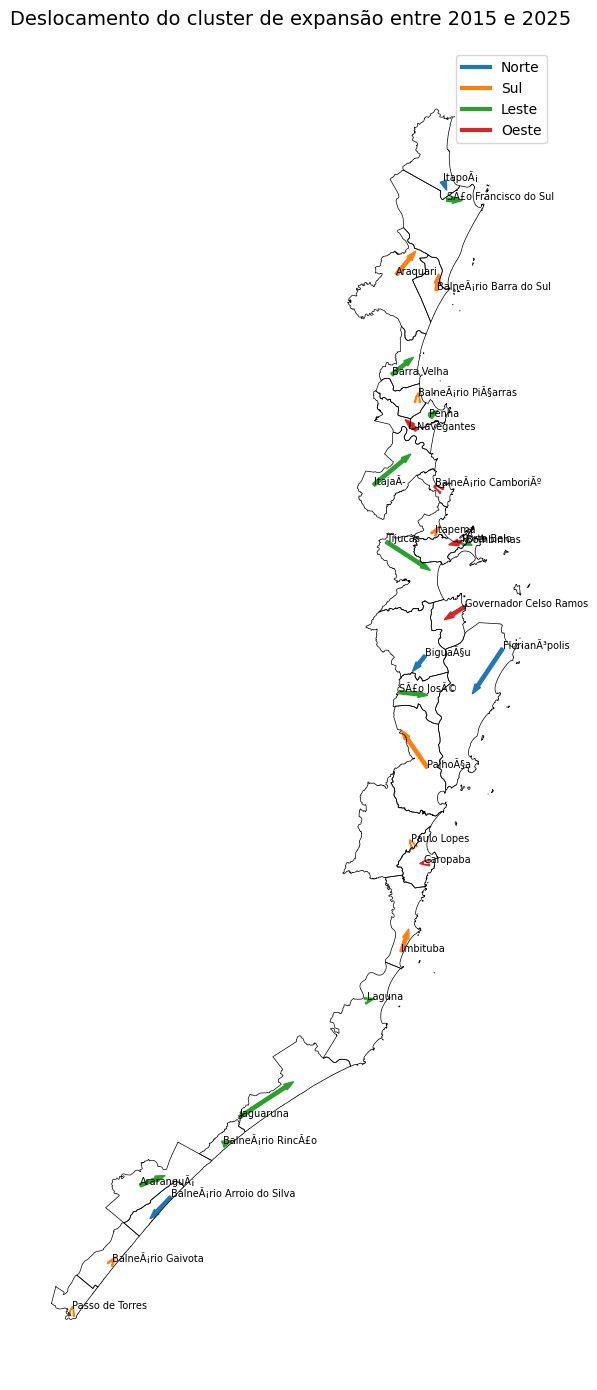

In [12]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# Shapefile dos municípios
cities = gpd.read_file("LITORAL_SC_REPROJETADO.shp")

# CSV com a análise consolidada
analysis = pd.read_csv("municipality_analysis.csv")

# Garantir que os códigos tenham o mesmo tipo
cities["CD_MUN"] = cities["CD_MUN"].astype(int)
analysis["city_code"] = analysis["city_code"].astype(int)

# Junta shapefile e resultados
gdf = cities.merge(
    analysis,
    left_on="CD_MUN",
    right_on="city_code"
)

# Cores para cada direção
direction_colors = {
    "NORTH": "#1f77b4",  # azul
    "SOUTH": "#ff7f0e",  # laranja
    "EAST": "#2ca02c",  # verde
    "WEST": "#d62728"   # vermelho
}

fig, ax = plt.subplots(figsize=(10, 14))

# Limites dos municípios
gdf.boundary.plot(
    ax=ax,
    linewidth=0.5,
    color="black"
)

# Desenha as setas
for _, row in gdf.iterrows():

    color = direction_colors.get(
        row["shift_direction"],
        "gray"
    )

    x1 = row["centroid_x_2015"]
    y1 = row["centroid_y_2015"]

    dx = row["dx_shift"]
    dy = row["dy_shift"]

    ax.arrow(
        x1,
        y1,
        dx,
        dy,
        color=color,
        width=1000,
        head_width=2000,
        length_includes_head=True,
        alpha=1
    )

    # Nome do município (opcional)
    ax.text(
        x1,
        y1,
        row["city_name"],
        fontsize=7
    )

# Legenda
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color=direction_colors["NORTH"], lw=3, label="Norte"),
    Line2D([0], [0], color=direction_colors["SOUTH"], lw=3, label="Sul"),
    Line2D([0], [0], color=direction_colors["EAST"], lw=3, label="Leste"),
    Line2D([0], [0], color=direction_colors["WEST"], lw=3, label="Oeste")
]

ax.legend(handles=legend_elements)

ax.set_title(
    "Deslocamento do cluster de expansão entre 2015 e 2025",
    fontsize=14
)

ax.set_axis_off()
plt.tight_layout()
plt.show()

In [ ]:
# Comprime a pasta de processados para um zip
!zip -r processed.zip /content/processed

# Baixa o zip no computador
from google.colab import files
files.download('processed.zip')

  adding: content/processed/ (stored 0%)
  adding: content/processed/summaries/ (stored 0%)
  adding: content/processed/summaries/4202073_BalneÃ¡rio Gaivota_overall.csv (deflated 44%)
  adding: content/processed/summaries/4212809_BalneÃ¡rio PiÃ§arras_last_year.csv (deflated 42%)
  adding: content/processed/summaries/4208203_ItajaÃ­_first_year.csv (deflated 44%)
  adding: content/processed/summaries/4212502_Penha_first_year.csv (deflated 44%)
  adding: content/processed/summaries/4208302_Itapema_first_year.csv (deflated 44%)
  adding: content/processed/summaries/4212304_Paulo Lopes_overall.csv (deflated 43%)
  adding: content/processed/summaries/4208203_ItajaÃ­_last_year.csv (deflated 43%)
  adding: content/processed/summaries/4202057_BalneÃ¡rio Barra do Sul_last_year.csv (deflated 44%)
  adding: content/processed/summaries/4209409_Laguna_last_year.csv (deflated 45%)
  adding: content/processed/summaries/4201950_BalneÃ¡rio Arroio do Silva_first_year.csv (deflated 44%)
  adding: content/

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>